## Pneumonia Classification CNN

#### COMP4388: Machine Learning
#### Abduallah Aabed

### Introduction

In this project I'm using Convolutional Neural Networks to classify images into pre-defined categories. The task is to train a model that will detect if a chest x-ray image is diagnosed with Pneumonia or not.

### Background and theory

First of, let's simply understand the Pneumonia and existing solutions for it's classifications.

### Medical Defention, quick symptons and causes
**Pneumonia** is an inflammatory infection of the lungs' air sacs that causes them to fill with fluid or pus, resulting in symptoms ranging from a productive cough and chest pain to fever, chills, and difficulty breathing. It is primarily caused by infectious agents such as bacteria, viruses, and fungi, or by the accidental aspiration of food or liquids into the lungs. While many cases present as a severe flu-like illness, the condition can be life-threatening, particularly for infants, adults over 65, and those with weakened immune systems or chronic respiratory conditions. [1]

### Solutions in classification for Pneumonia

#### 1. Traditional Machine learning 
Like most of image classification problems, before deep learning, solutions have relied om Traditional Machine Learning solution. the reserach manually worked on feature engineering to specify the patterns in infected lungs like texture and shape, then they used the extracted features to feed to traditional ML algortihms like SVM and KNNs.

These solution are limited to capture the complex patterns in the images.

#### 2. CNN
After convultional neural networks CNNs there was no need to manually do the feature extractions. The development and design of CNN layers has allowed to use the pre-trained models and improve and result on high accuracy. However, this solution requires large datasets.

#### 3. Transformers

Transformers currently results in higher accuracy and it requires a high compuatioanl cost.

### Dataset:
- The dataset that used in this work is the Chest X-Ray dataset.downloaded through the row images of the dataset here Version (roboflow.com). https://universe.roboflow.com/mohamed-traore-2ekkp/chest-x-rays-qjmia/dataset/4
  
- Since the environment used to run this code is on kaggle, I have utilized the same dataset uploaded to kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia [1]

The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). 

There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal). 


Here is an example from the dataset on how the Pneumonia actually looks like in the x-ray:


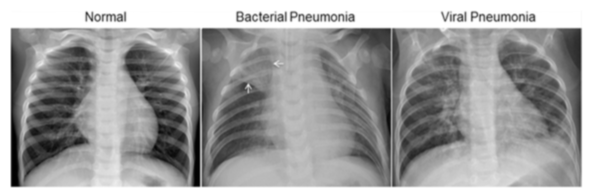


The Dataset original source is: https://data.mendeley.com/datasets/rscbjbr9sj/2

Under License: CC BY 4.0

Citation: http://www.cell.com/cell/fulltext/S0092-8674(18)30154-5

### Tools

Kaggle environemnt, 

## Important libaries for this project

To run this project the following is imported

In [1]:
import numpy as np
import pandas as pd 
import os
import pandas as pd
import random
import math
import PIL
from matplotlib import pyplot as plt

In [2]:

def load_dataset_splits(base_path):
    """
    Reads the chest_xray directory and creates dataframes for train, test, and val.
    
    Structure expected:
    base_path/train/NORMAL/image.jpeg
    base_path/train/PNEUMONIA/image.jpeg
    """
    splits = ['train', 'test', 'val']
    dataframes = {}

    for split in splits:
        labels = []
        filepaths = []
        split_path = os.path.join(base_path, split)
        
        # Check if the split folder exists (val is sometimes empty or missing)
        if not os.path.exists(split_path):
            continue

        for folder in os.listdir(split_path):
            label_path = os.path.join(split_path, folder)
            
            if os.path.isdir(label_path):
                for image in os.listdir(label_path):
                    # Filter for image files only
                    if image.lower().endswith(('.jpeg', '.jpg', '.png')):
                        filepaths.append(os.path.join(label_path, image))
                        labels.append(folder)
        
        dataframes[split] = pd.DataFrame({
            'ImagePath': filepaths,
            'Label': labels
        })

    return dataframes.get('train'), dataframes.get('test'), dataframes.get('val')

In [3]:

# Usage (based on your Kaggle path)
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'
train_df, test_df, val_df = load_dataset_splits(base_path)

In [4]:
train_df.sample(10)

,ImagePath,Label
3828,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
566,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
2972,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
471,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4570,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
2238,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4432,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
3418,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1664,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
2684,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA


In [5]:
train_df['Label'].value_counts()

Label
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64

In [6]:
def show_random_samples(df, num):
    """
    Shows a sample on the dataframe in a specific location.
    Args:
        df (pd.DataFrame): the dataset
        num (int): the number of random samples to display
    Return:
        Nothing but shows a sample in the display
    """
    random.seed(1190652)
    random_indices = random.sample(range(df.shape[0]), num)
    num_rows = math.ceil(num / 4) 

    fig, axes = plt.subplots(num_rows, 4, figsize=(20, num_rows * 5))  
    for i, idx in enumerate(random_indices):
        row = i // 4
        col = i % 4
        
        if idx < df.shape[0]:  
            image_path =  df.loc[idx, "ImagePath"]
            image = PIL.Image.open(image_path)
            ax = axes[row, col] if num_rows > 1 else axes[col]
            ax.imshow(image, cmap='gray')
            ax.set_title(f"Image {idx} Diagnosis: {df.loc[idx, 'Label']}")
            ax.axis("off")

    plt.suptitle("Random Small Sample of the Dataset")
    plt.tight_layout()
    plt.show()

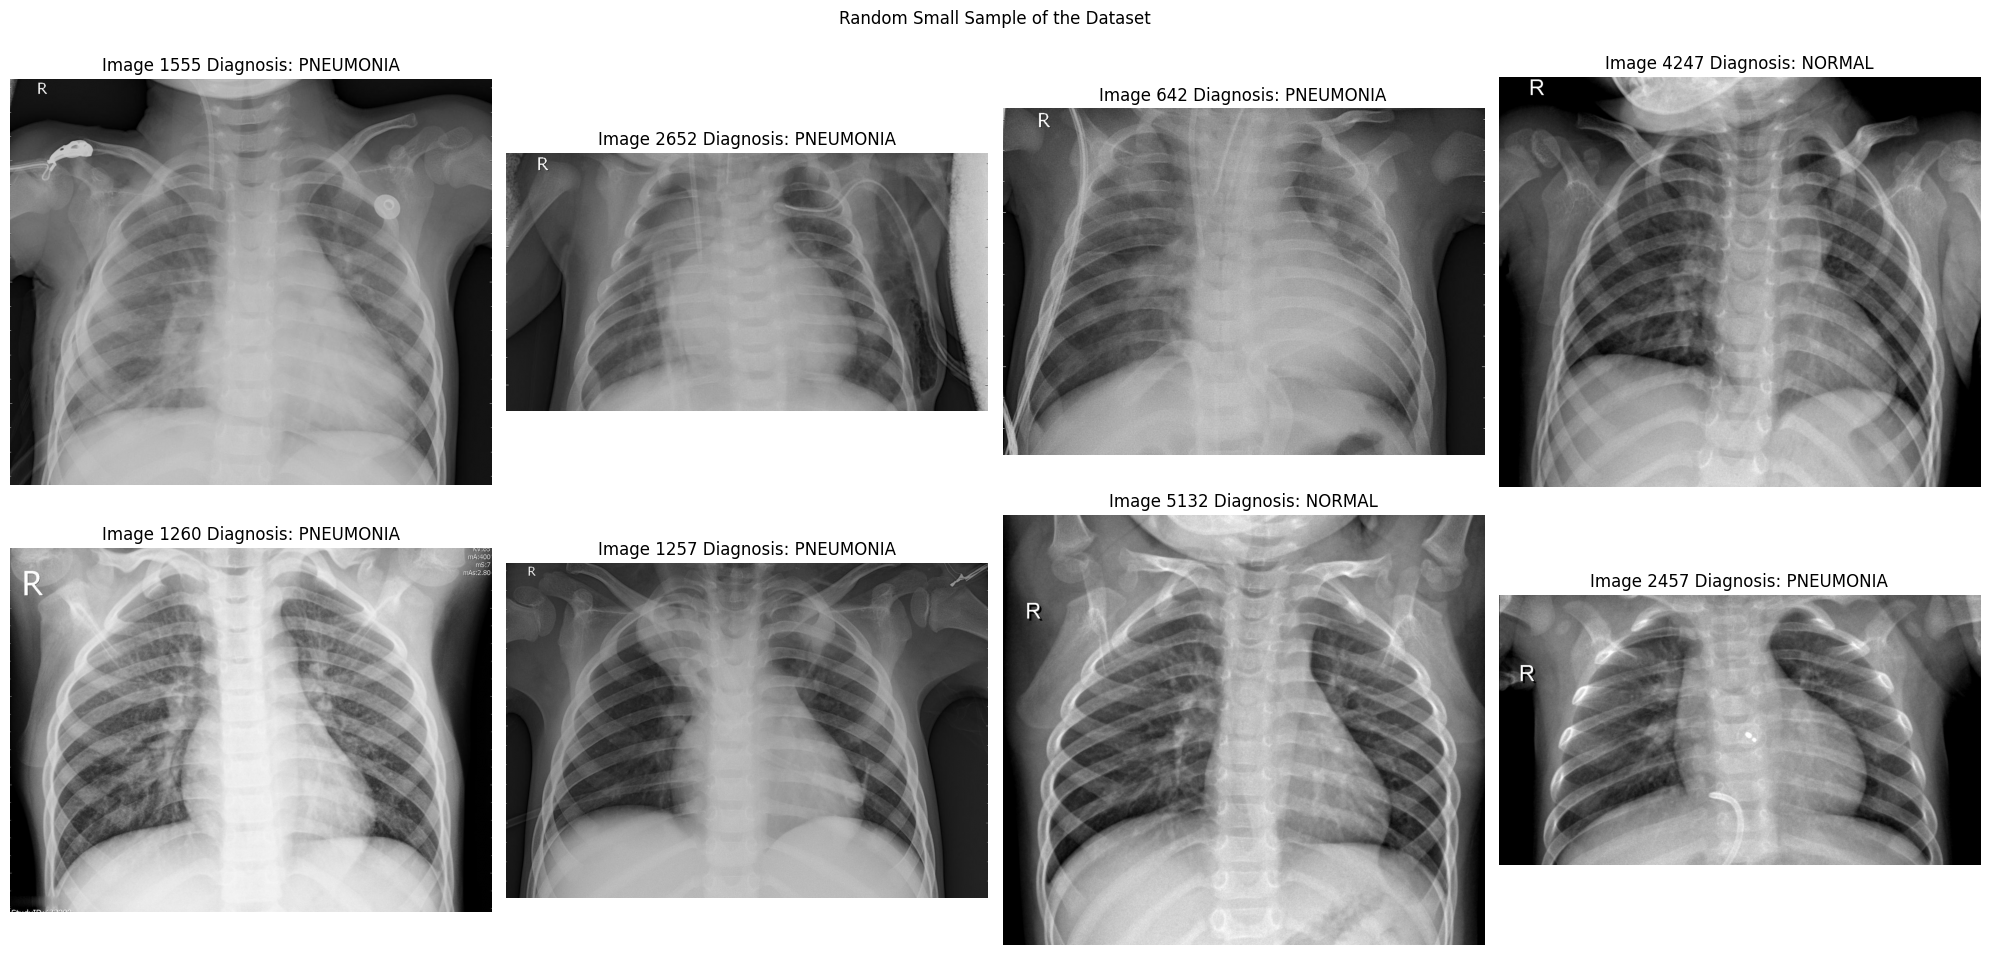

In [7]:
show_random_samples(train_df, 8)

The width of the images:  1300
The height of the images:  890
Shape (1300, 890)


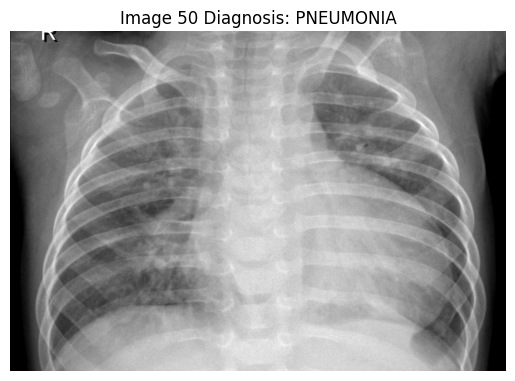

In [8]:
image_path =  train_df.loc[50, "ImagePath"]
image = PIL.Image.open(image_path)
plt.imshow(image, cmap='gray')
plt.title(f"Image {50} Diagnosis: {train_df.loc[50, 'Label']}")
plt.axis("off")
width, height = image.size
print("The width of the images: ", width)
print("The height of the images: ", height)
print("Shape", image.size)

The width of the images:  824
The height of the images:  568
Shape (824, 568)


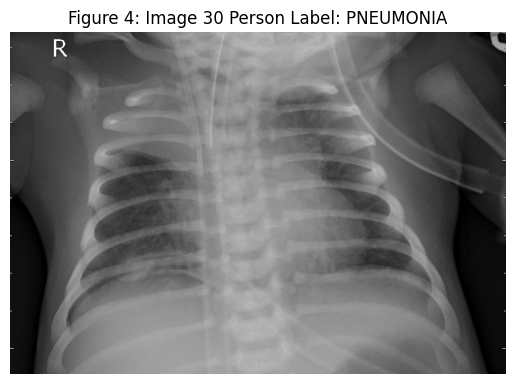

In [9]:
image_path =  train_df.loc[30, "ImagePath"]
image = PIL.Image.open(image_path)
plt.imshow(image, cmap='gray')
plt.title(f"Figure 4: Image {30} Person Label: {train_df.loc[30, 'Label']}")
plt.axis("off")
width, height = image.size
print("The width of the images: ", width)
print("The height of the images: ", height)
print("Shape", image.size)

In [10]:
image_sizes = []
aspect_ratios = []

for image_path in train_df['ImagePath']:
    image = PIL.Image.open(image_path)
    width, height = image.size
    image_sizes.append(width * height)
    aspect_ratios.append(width / height)

Text(0, 0.5, 'Frequency')

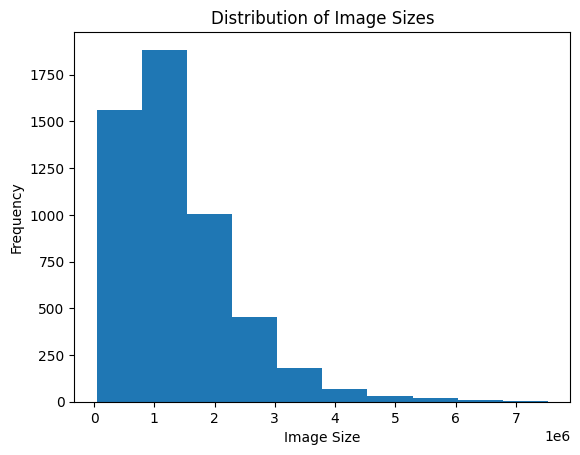

In [11]:
plt.hist(image_sizes, label="Image Size")
plt.title("Distribution of Image Sizes")
plt.xlabel("Image Size")
plt.ylabel("Frequency")

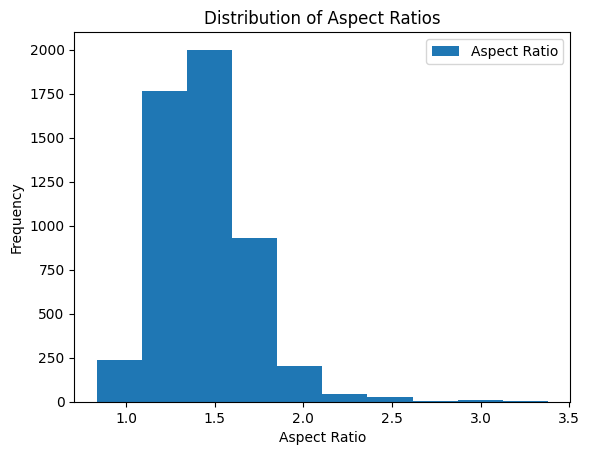

In [12]:
plt.hist(aspect_ratios, label="Aspect Ratio")
plt.title("Distribution of Aspect Ratios")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.legend()


### Main Task:
- The main task is to Train a CNN model. 
- The design is either my own architecture or use existing architecture. 
- the architecture details is specified used either you designed it or cite existing literature on what did you use.


### Outline
In this Report the results and experiments are shown, provided the following: 

- A: The architecture used to train CNNs.
- B: performance Comparison of the new model against a CNN model with the following specification: 
    - 1 convolutional layer (non-overlapping filters), 
    - 1 average pooling layer, 
    - fully connected NN.

- C: Performance Report of both models.: 
    - the Accuracy,
    - Precision, 
    - Recall, 
    - F1-Score of

- D: Class confusion matrix
    Provide the Class confusion matrix of the classification output for both classifiers.

- E: Insights and interpretations of the results (discussions).

- F: the code


## Refrences:
- [1] Dataset: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia 
- [2] https://www.mayoclinic.org/diseases-conditions/pneumonia/symptoms-causes/syc-20354204